# Fine-Tuning and Quantization of MobileNetV3 for AI Deck

This notebook demonstrates the process of fine-tuning a pre-trained MobileNetV3Small model on a custom dataset and quantizing it for deployment on the AI Deck. The AI Deck is a powerful tool for running lightweight AI models on drones, and optimizing models for it involves careful consideration of size, accuracy, and compatibility.

The notebook is divided into the following sections:

1. **Data Preparation**: Loading and augmenting the dataset.
2. **Model Definition**: Setting up a MobileNetV3-based architecture.
3. **Training**: Fine-tuning the model for our custom dataset.
4. **Evaluation**: Assessing the model's performance.
5. **Model Conversion and Quantization**: Preparing the model for deployment on the AI Deck.
6. **Testing the Quantized Model**: Verifying the functionality of the quantized model.

## Prerequisites

Before running this notebook, ensure you have the following installed and configured:

1. **Python Environment**:
   - Python 3.8–3.11
   - A virtual environment or Conda environment is recommended to manage dependencies.

2. **Required Libraries**:
   - `TensorFlow >= 2.10`
   - `NumPy`
   - `Pandas`
   - `Matplotlib`
   - `Pillow`
   - `SciPy`
   - `Seaborn`
   - `PyDot`
   - `GraphViz`

   You can install the required libraries with:
   ```bash
   pip install tensorflow numpy pandas matplotlib pillow scipy pydot

   sudo apt install graphviz
   ```

3. **Dataset**:

   - A labeled dataset organized in the following structure:

    training_data/
      train/
        class1/
        class2/
        ...
      validation/
        class1/
        class2/
        ...

   - Ensure the dataset is prepared with appropriate augmentations for training.
   - For a quick start, you can use the provided example dataset: `training_data/training_data_christmas_packet.zip` Extract the archive to a folder before running the notebook.

4. **Hardware**:

   - A GPU-enabled machine is recommended for faster training.
    Ensure TensorFlow is configured to use your GPU if available.

5. **AI Deck Environment (for deployment)**:

   - Install the necessary tools and libraries to work with the AI Deck.

Refer to the official [AI Deck documentation](https://www.bitcraze.io/documentation/tutorials/getting-started-with-aideck/) documentation for setup instructions or README.

In [6]:
#!pip install tensorflow numpy pandas matplotlib pillow scipy pydot
#!sudo apt install graphviz

## Imports

In [7]:
import os
import argparse
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
import zipfile

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Resizing,
    Conv2D,
    GlobalAveragePooling2D,
    Dropout,
    Dense
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical # Import to_categorical

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import numpy as np

## Prepare the Dataset and Initialize Arguments
This section uses command-line style argument parsing adapted for the notebook environment. It initializes parameters and ensures the dataset is prepared.

In [8]:
#from google.colab import drive
#drive.mount("/content/drive", force_remount=True)
# Create folders for models and data

# DRIVE_PATH = '/content/drive/MyDrive/aideck'
DRIVE_PATH = f"{os.path.abspath(os.curdir)}"
os.makedirs(DRIVE_PATH, exist_ok=True)

# Emulate argparse in Jupyter
class Args:
    epochs = 80
    finetune_epochs = 40
    dataset_path = "training_data"
    batch_size = 64
    image_width = 32 # CIFAR image width
    image_height = 32 # CIFAR image height
    image_channels = 3
    print_plot = True

args = Args()


## Load MNIST dataset
#(train_images_np, train_labels_np), (val_images_np, val_labels_np) = tf.keras.datasets.mnist.load_data()

# Load CIFAR-10 data, which is already RGB
(train_images_np, train_labels_np), (val_images_np, val_labels_np) = tf.keras.datasets.cifar10.load_data()
num_classes = 10
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Dynamically determine image shape and channels from the loaded data
image_height, image_width = train_images_np.shape[1:3]
if len(train_images_np.shape) == 3:
    image_channels = 1
else:
    image_channels = train_images_np.shape[3]

print(f"Detected image shape: {image_height}x{image_width}, Channels: {image_channels}")

args.image_width = image_width
args.image_height = image_height
args.image_channels = image_channels

# Convert numpy arrays to TensorFlow tensors
train_images = tf.convert_to_tensor(train_images_np, dtype=tf.float32)
val_images = tf.convert_to_tensor(val_images_np, dtype=tf.float32)
train_labels = tf.convert_to_tensor(train_labels_np, dtype=tf.int64)
val_labels = tf.convert_to_tensor(val_labels_np, dtype=tf.int64)

# Scale pixel values to [0, 1]
train_images = train_images / 255.0
val_images = val_images / 255.0

# Add channel dimension if needed
if len(train_images.shape) == 3:
    train_images = train_images[..., None]
    val_images = val_images[..., None]

# Convert grayscale to RGB if needed
if train_images.shape[-1] == 1 and args.image_channels == 3:
    train_images = tf.image.grayscale_to_rgb(train_images)
    val_images = tf.image.grayscale_to_rgb(val_images)
    print(f"Converted images to RGB. Train shape: {train_images.shape}, Val shape: {val_images.shape}")
else:
    print(f"Keeping images as grayscale. Train shape: {train_images.shape}, Val shape: {val_images.shape}")


# 6) One-hot encode labels
num_classes = 10
train_labels = to_categorical(train_labels.numpy(), num_classes) # Convert back to NumPy for to_categorical
val_labels   = to_categorical(val_labels.numpy(), num_classes) # Convert back to NumPy for to_categorical


# Data augmentation for the training dataset
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    # rescale=1.0 / 255.0,  # Normalization already done above
    # rotation_range=15,  # Randomly rotate images within ±15°
    # shear_range=0.2,  # Apply random shearing transformations up to 20%
    # zoom_range=0.2,  # Randomly zoom in/out up to ±20%
    # width_shift_range=0.1,  # Horizontally shift images by up to 10%
    # height_shift_range=0.1,  # Vertically shift images by up to 10%
    # horizontal_flip=True,  # Allow horizontal flipping of images
    # vertical_flip=False,  # Skip vertical flipping (not logical for this dataset)
    # brightness_range=[0.5, 1.5]  # Randomly adjust brightness between 50% and 150%
)

# Data augmentation for the validation dataset
# Only rescaling is applied to ensure consistency in validation
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    # rescale=1.0 / 255.0  # Normalization already done above
)


train_generator = train_datagen.flow(
    train_images.numpy(), # Convert back to NumPy for the generator
    train_labels,
    batch_size=args.batch_size,
    shuffle=True
)


# Validation generator—only rescaling (already in [0,1])
val_datagen = ImageDataGenerator()
val_generator = val_datagen.flow(
    val_images.numpy(), # Convert back to NumPy for the generator
    val_labels,
    batch_size=args.batch_size,
    shuffle=False
)

# 8) Save class labels (0–9) for later inference
labels = [str(i) for i in range(num_classes)]
with open(os.path.join(DRIVE_PATH, "class_labels.txt"), "w") as f:
    f.write("\n".join(labels))

print("MNIST is ready. Classes:", labels)

Detected image shape: 32x32, Channels: 3
Keeping images as grayscale. Train shape: (50000, 32, 32, 3), Val shape: (10000, 32, 32, 3)
MNIST is ready. Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


## Model Building and Training

In this section, we will define the architecture of the neural network using MobileNetV3Small as the base model. The model will then be trained using the prepared dataset. The training will be conducted in two stages: initial training with frozen weights of the base model, and fine-tuning with unfrozen weights.


Detected RGB images, resizing only.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ resizing_1 (Resizing)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer_3 (InputLayer) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ rescaling (Rescaling)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv (Conv2D)              │ (None, 112, 112, 16)   │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv_bn                    │ (None, 112, 112, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ activation (Activation)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └                            │ (None, 113, 113, 16)   │             0 │
│ expanded_conv_depthwise_pad     │                        │               │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ expanded_conv_depthwise    │ (None, 56, 56, 16)     │           144 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ expanded_conv_depthwise_bn │ (None, 56, 56, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ re_lu (ReLU)               │ (None, 56, 56, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └                            │ (None, 1, 1, 16)       │             0 │
│ expanded_conv_squeeze_excite_a… │                        │               │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └                            │ (None, 1, 1, 8)        │           136 │
│ expanded_conv_squeeze_excite_c… │                        │               │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └                            │ (None, 1, 1, 8)        │             0 │
│ expanded_conv_squeeze_excite_r… │                        │               │
│ (ReLU)                          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └                            │ (None, 1, 1, 16)       │           144 │
│ expanded_conv_squeeze_excite_c… │                        │               │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ re_lu_1 (ReLU)             │ (None, 1, 1, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └                            │ (None, 56, 56, 16)     │             0 │
│ expanded_conv_squeeze_excite_m… │                        │             

 Total params: 1,105,370 (4.22 MB)

 Trainable params: 166,250 (649.41 KB)

 Non-trainable params: 939,120 (3.58 MB)

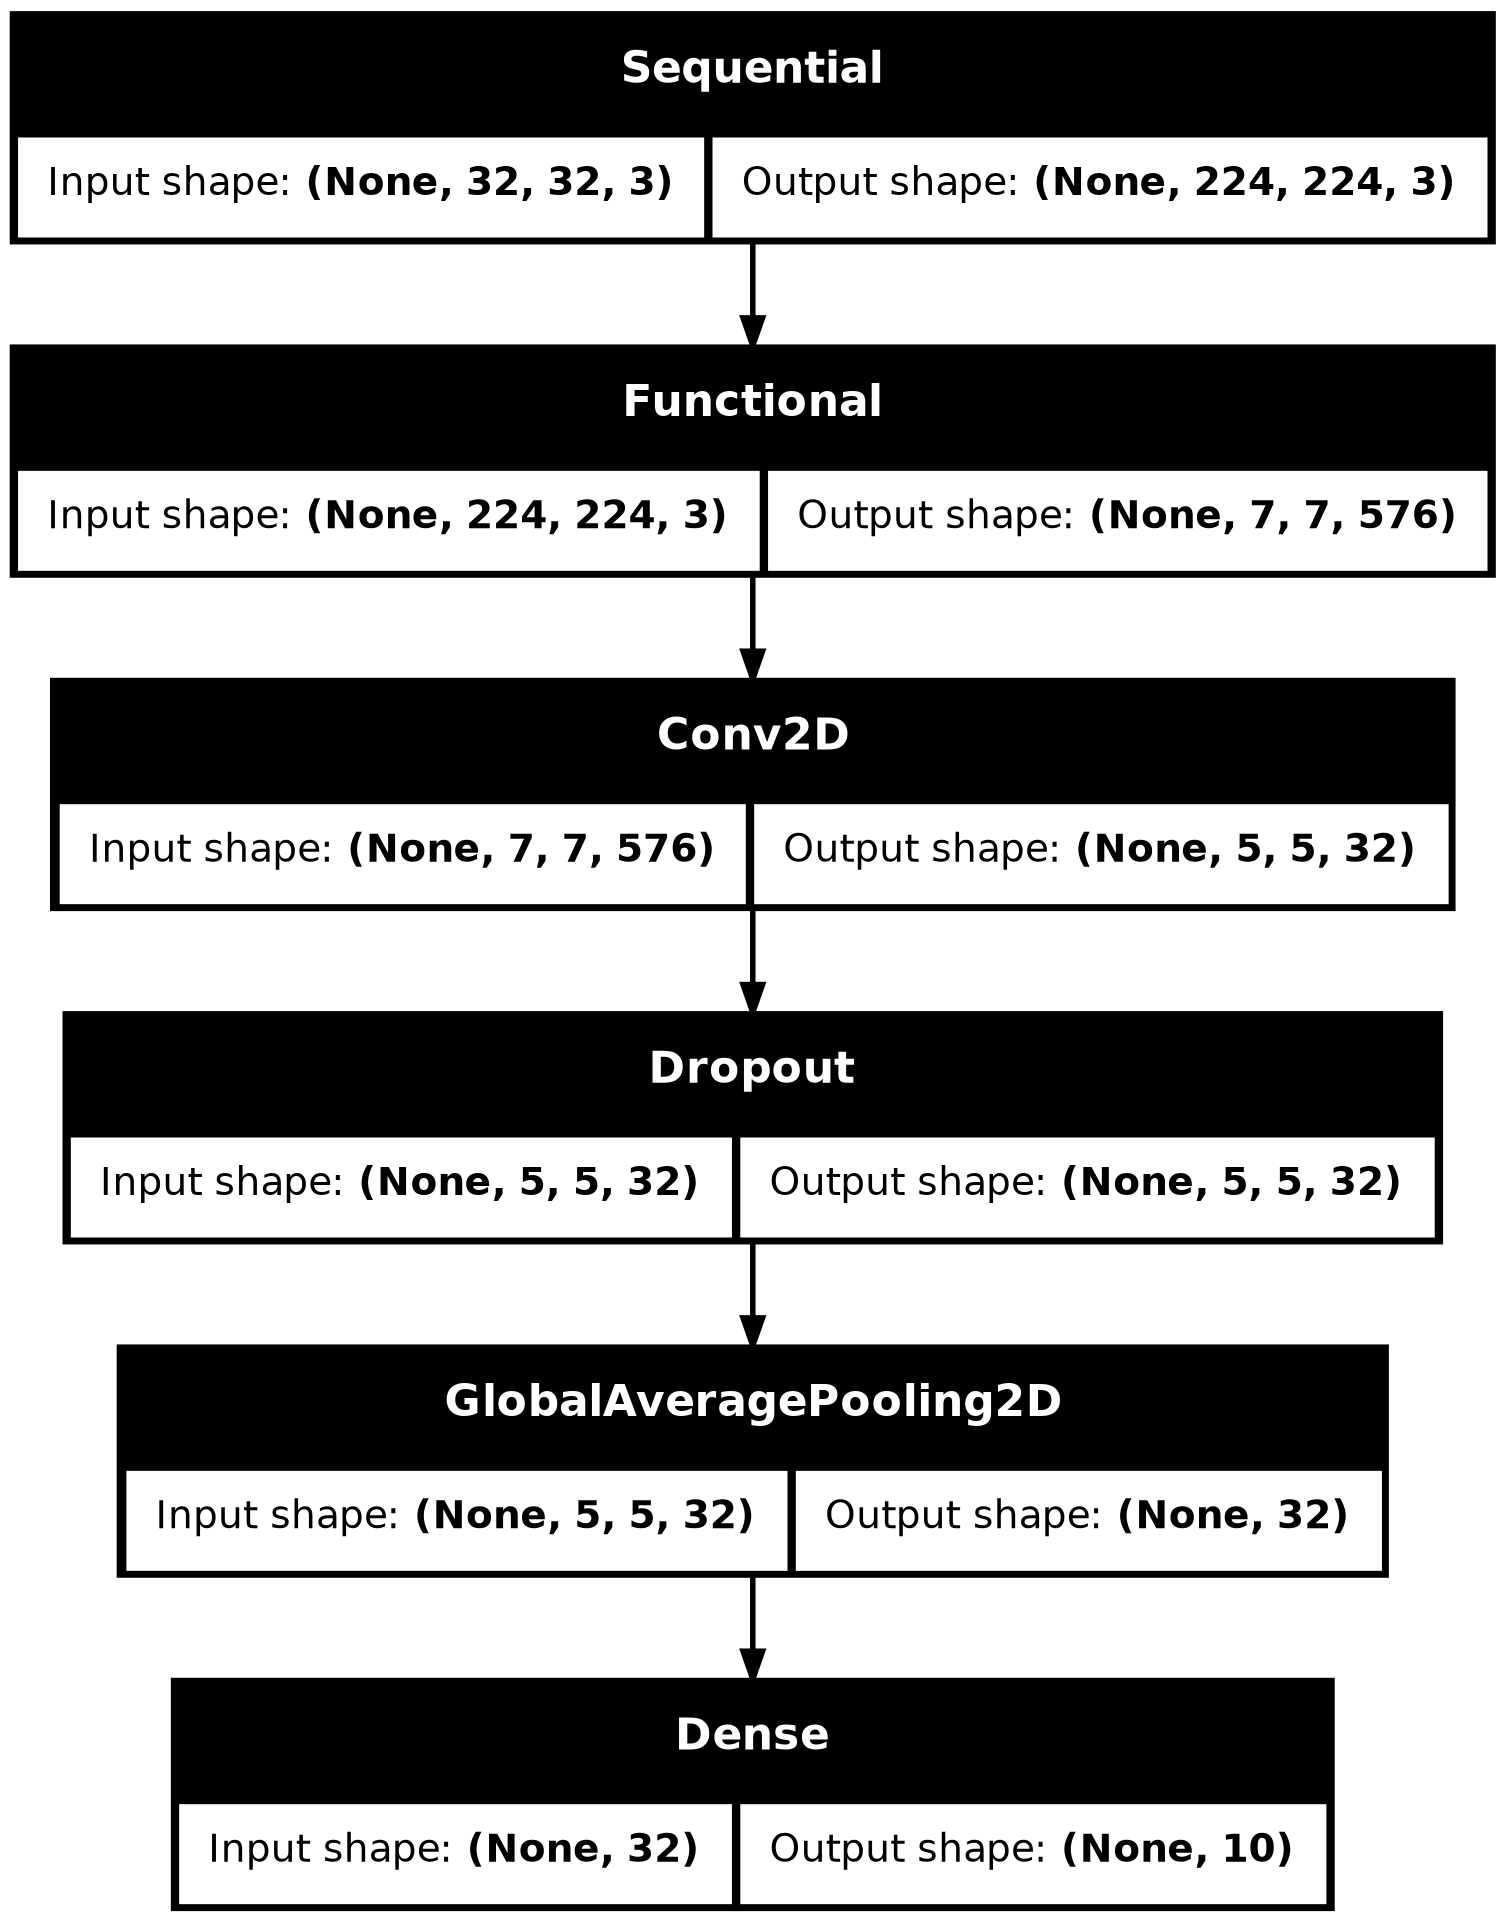

In [9]:
# Define the model architecture
base_model = MobileNetV3Small(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
#base_model = MobileNetV2(
#    input_shape=(224, 224, 3),
#    include_top=False,
#    weights="imagenet"
#)
base_model.trainable = False  # Freeze the base model for initial training

if args.image_channels == 1:
    print("Detected grayscale images, adding conversion layer.")
    input_layer = tf.keras.Sequential([
        tf.keras.Input(shape=(args.image_width, args.image_height, 1)),
        tf.keras.layers.Conv2D(filters=3, kernel_size=(1, 1), activation=None),
        tf.keras.layers.Resizing(224, 224, interpolation="bilinear")
    ])
else:
    print("Detected RGB images, resizing only.")
    input_layer = tf.keras.Sequential([
        tf.keras.Input(shape=(args.image_width, args.image_height, 3)),
        tf.keras.layers.Resizing(224, 224, interpolation="bilinear")
    ])

# Add custom layers on top of the base model
model = Sequential([
    input_layer,
    base_model,
    tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu'), # Example: 64 filters, 3x3 kernel
    Dropout(0.2),
    GlobalAveragePooling2D(),
    Dense(units=num_classes, activation="softmax")
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.build(input_shape=(None, args.image_width, args.image_height, args.image_channels))
model.summary(expand_nested=True)
tf.keras.utils.plot_model(model, show_shapes=True)

In [10]:
# Early stopping to terminate training when validation loss stops improving
early_stopping = EarlyStopping(
    monitor='val_loss',          # Monitors validation loss
    patience=5,                  # Number of epochs without improvement before stopping
    verbose=1,                   # Print messages when stopping
    restore_best_weights=True    # Reverts to the best weights after stopping
)

# Learning rate scheduler to reduce learning rate when validation loss plateaus
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',          # Monitors validation loss
    factor=0.5,                  # Reduces the learning rate by a factor (e.g., halves it)
    # cooldown=5,
    patience=3,                  # Number of epochs without improvement before reducing learning rate
    verbose=1,                   # Print messages when reducing learning rate
    min_lr=1e-6                  # Minimum allowed learning rate
)


# Train the model
max_epochs = args.epochs
history = model.fit(
    train_generator,                            # Training data generator
    validation_data=val_generator,              # Validation data generator
    epochs=max_epochs,                          # Maximum number of epochs
    callbacks=[early_stopping, lr_scheduler]    # List of callbacks
)

Epoch 1/80


/home/zboucek/anaconda3/envs/tf/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 239s 301ms/step - accuracy: 0.1048 - loss: 2.3072 - val_accuracy: 0.1022 - val_loss: 2.2998 - learning_rate: 1.0000e-04
Epoch 2/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 195s 250ms/step - accuracy: 0.1137 - loss: 2.2992 - val_accuracy: 0.1719 - val_loss: 2.2943 - learning_rate: 1.0000e-04
Epoch 3/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 201s 256ms/step - accuracy: 0.1276 - loss: 2.2939 - val_accuracy: 0.1456 - val_loss: 2.2860 - learning_rate: 1.0000e-04
Epoch 4/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 218s 279ms/step - accuracy: 0.1417 - loss: 2.2851 - val_accuracy: 0.1676 - val_loss: 2.2741 - learning_rate: 1.0000e-04
Epoch 5/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 179s 229ms/step - accuracy: 0.1595 - loss: 2.2731 - val_accuracy: 0.2019 - val_loss: 2.2626 - learning_rate: 1.0000e-04
Epoch 6/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 172s 221ms/step - accuracy: 0.1660 - loss: 2.2619 - val_accuracy: 0.1933 - val_loss: 2.2505 - learning_rate: 1.0000e-04
Epoch 7/80
782/782 ━━━━━━━━━━━━━━━━━━━━ 173s 221ms/

## Saving the Trained Model without Fine-Tuning and Evaluating Its Performance

Once the model has been trained, we save it for later use and evaluate its performance. The evaluation metrics include accuracy on both the training and validation datasets. This step ensures that the model is saved in a reusable format for conversion or deployment.

In [11]:
# Define paths to save the model
model_save_dir = os.path.join(os.getcwd(), "model")
os.makedirs(model_save_dir, exist_ok=True)
model_save_path = os.path.join(model_save_dir, "model_no_finetune.keras")

# Save the model in .keras format
model.save(model_save_path)
print(f"Model saved to: {model_save_path}")

# Evaluate the model on the validation dataset
val_loss, val_accuracy = model.evaluate(val_generator, verbose=1)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4%}")

Model saved to: /home/zboucek/mygit/cf/aideck-gap8-examples/examples/ai/classification/model/model_no_finetune.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 178ms/step - accuracy: 0.3436 - loss: 1.8112
Validation Loss: 1.8193
Validation Accuracy: 33.7400%


## Training Progress without Fine-Tuning Visualization

In this section, we visualize the training progress using loss and accuracy metrics for both training and validation data. These plots help us understand whether the model is improving over time and if there are signs of overfitting or underfitting.

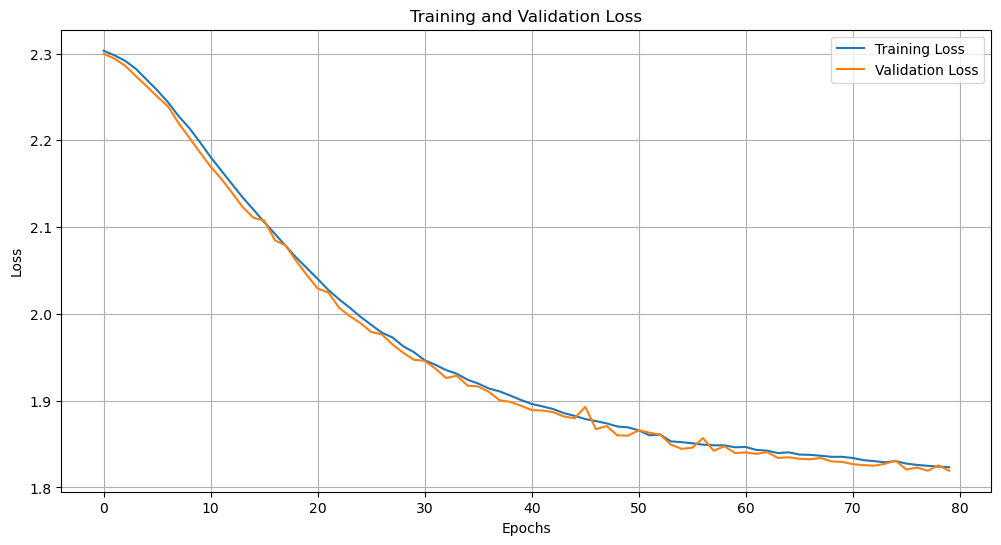

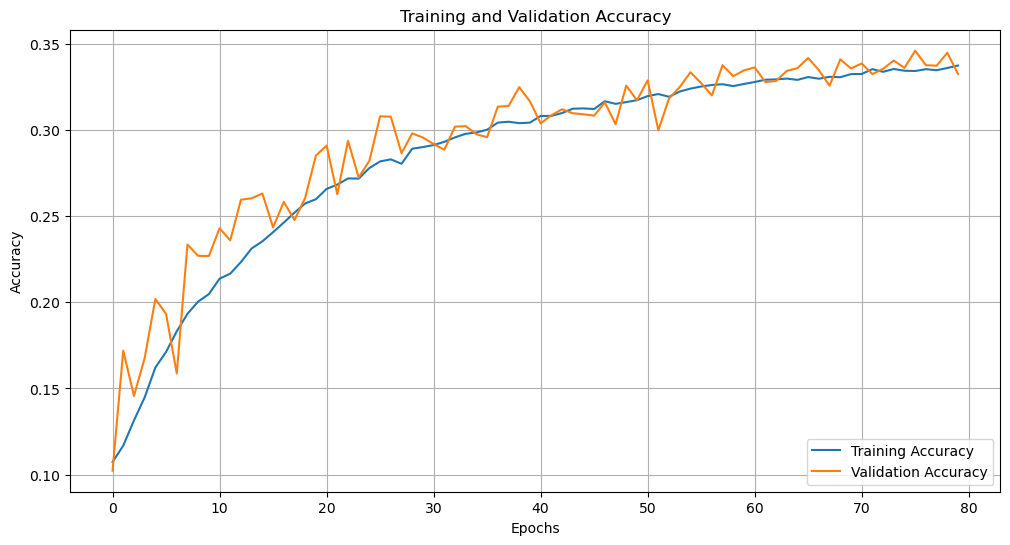

157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 366ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.32      0.36      0.34      1000
           1       0.46      0.42      0.44      1000
           2       0.26      0.32      0.29      1000
           3       0.27      0.01      0.02      1000
           4       0.25      0.26      0.26      1000
           5       0.28      0.47      0.35      1000
           6       0.34      0.28      0.31      1000
           7       0.31      0.38      0.34      1000
           8       0.46      0.42      0.44      1000
           9       0.44      0.46      0.45      1000

    accuracy                           0.34     10000
   macro avg       0.34      0.34      0.32     10000
weighted avg       0.34      0.34      0.32     10000



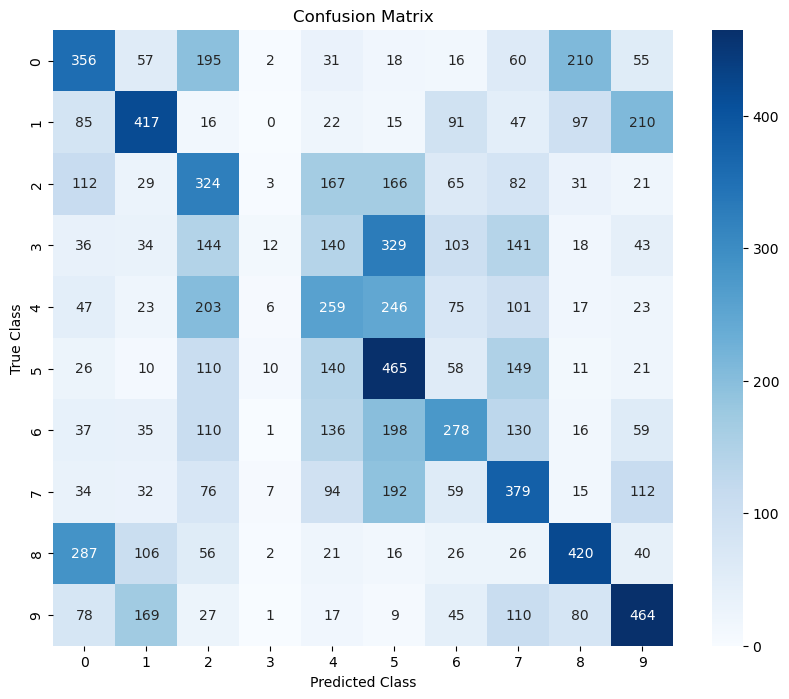

In [13]:
import matplotlib.pyplot as plt

# Retrieve history data
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs_range = range(len(train_loss))

# Plot Loss
plt.figure(figsize=(12, 6))
plt.plot(epochs_range, train_loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

# Plot Accuracy
plt.figure(figsize=(12, 6))
plt.plot(epochs_range, train_accuracy, label="Training Accuracy")
plt.plot(epochs_range, val_accuracy, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Predict on validation data
# Use the original val_labels_np for true classes
val_predictions = model.predict(val_generator)
val_pred_classes = np.argmax(val_predictions, axis=1)

# Classification report
# Use the original val_labels_np for classification_report and confusion_matrix
# Since val_labels_np are integer labels, we need to convert the one-hot encoded val_labels back to integers
true_val_labels_int = np.argmax(val_labels, axis=1)
report = classification_report(true_val_labels_int, val_pred_classes, target_names=[str(i) for i in range(num_classes)]) # Use generated class names
print("Classification Report:\n")
print(report)

# Confusion matrix
conf_matrix = confusion_matrix(true_val_labels_int, val_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

## Saving the Trained Model and Evaluating Its Performance

Once the model has been trained, we save it for later use and evaluate its performance. The evaluation metrics include accuracy on both the training and validation datasets. This step ensures that the model is saved in a reusable format for conversion or deployment.

In [14]:
# Define paths to save the model
model_save_dir = os.path.join(os.getcwd(), "model")
os.makedirs(model_save_dir, exist_ok=True)
model_save_path = os.path.join(model_save_dir, "model.keras")

# Save the model in .keras format
model.save(model_save_path)
print(f"Model saved to: {model_save_path}")

# Evaluate the model on the validation dataset
val_loss, val_accuracy = model.evaluate(val_generator, verbose=1)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4%}")

Model saved to: /home/zboucek/mygit/cf/aideck-gap8-examples/examples/ai/classification/model/model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 52s 333ms/step - accuracy: 0.3436 - loss: 1.8112
Validation Loss: 1.8193
Validation Accuracy: 33.7400%


# Fine-Tune MobileNetV3

In [15]:

# Unfreeze the base model for fine-tuning
base_model.trainable = True
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Fine-tune the model
fine_tune_epochs = args.finetune_epochs
total_epochs = max_epochs + fine_tune_epochs
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1],
    callbacks=[early_stopping, lr_scheduler]  # Include callbacks
)

Epoch 80/120


782/782 ━━━━━━━━━━━━━━━━━━━━ 1110s 1s/step - accuracy: 0.2796 - loss: 23.5511 - val_accuracy: 0.1050 - val_loss: 3.5721 - learning_rate: 1.0000e-04
Epoch 81/120
782/782 ━━━━━━━━━━━━━━━━━━━━ 875s 1s/step - accuracy: 0.5461 - loss: 1.3089 - val_accuracy: 0.1199 - val_loss: 6.6329 - learning_rate: 1.0000e-04
Epoch 82/120
782/782 ━━━━━━━━━━━━━━━━━━━━ 875s 1s/step - accuracy: 0.6684 - loss: 0.9438 - val_accuracy: 0.1003 - val_loss: 7.6221 - learning_rate: 1.0000e-04
Epoch 83/120
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7454 - loss: 0.7307
Epoch 83: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
782/782 ━━━━━━━━━━━━━━━━━━━━ 876s 1s/step - accuracy: 0.7454 - loss: 0.7307 - val_accuracy: 0.1058 - val_loss: 4.3591 - learning_rate: 1.0000e-04
Epoch 84/120
782/782 ━━━━━━━━━━━━━━━━━━━━ 877s 1s/step - accuracy: 0.7955 - loss: 0.5885 - val_accuracy: 0.1361 - val_loss: 3.8919 - learning_rate: 5.0000e-05
Epoch 85/120
782/782 ━━━━━━━━━━━━━━━━━━━━ 879s 1s/step - accuracy

## Training Progress Visualization

In this section, we visualize the training progress using loss and accuracy metrics for both training and validation data. These plots help us understand whether the model is improving over time and if there are signs of overfitting or underfitting.

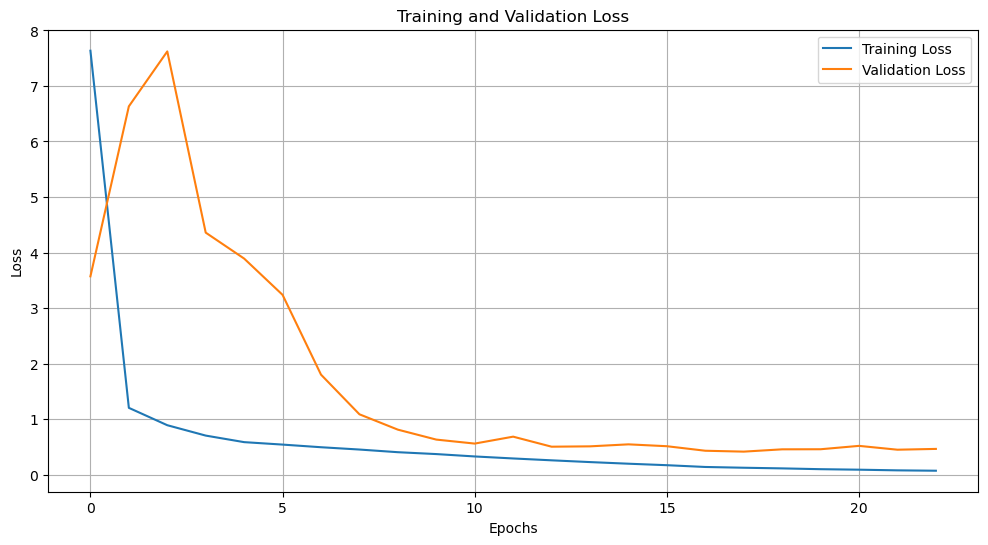

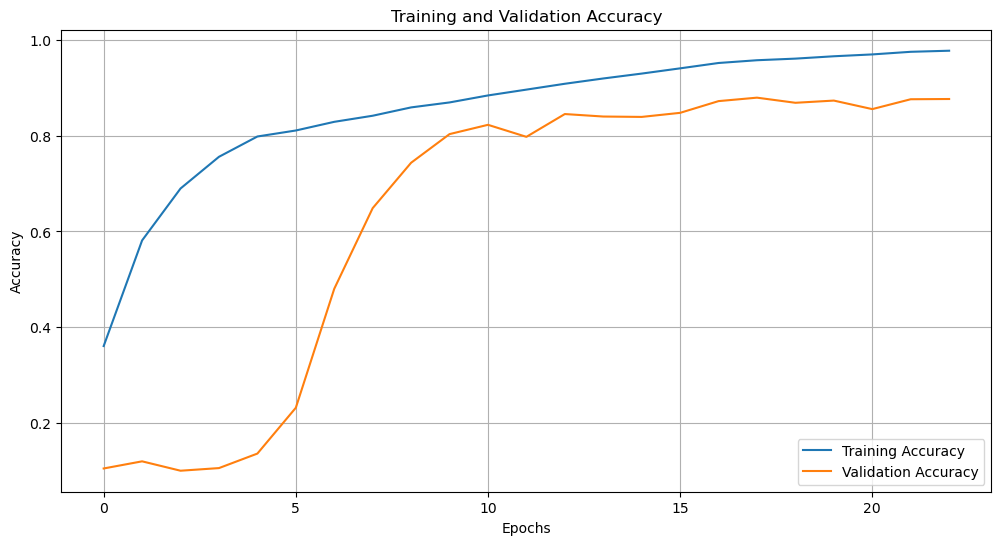

157/157 ━━━━━━━━━━━━━━━━━━━━ 52s 329ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.88      0.88      1000
           1       0.94      0.91      0.93      1000
           2       0.87      0.85      0.86      1000
           3       0.77      0.76      0.76      1000
           4       0.85      0.91      0.88      1000
           5       0.85      0.79      0.82      1000
           6       0.91      0.92      0.92      1000
           7       0.92      0.89      0.91      1000
           8       0.89      0.96      0.93      1000
           9       0.90      0.92      0.91      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



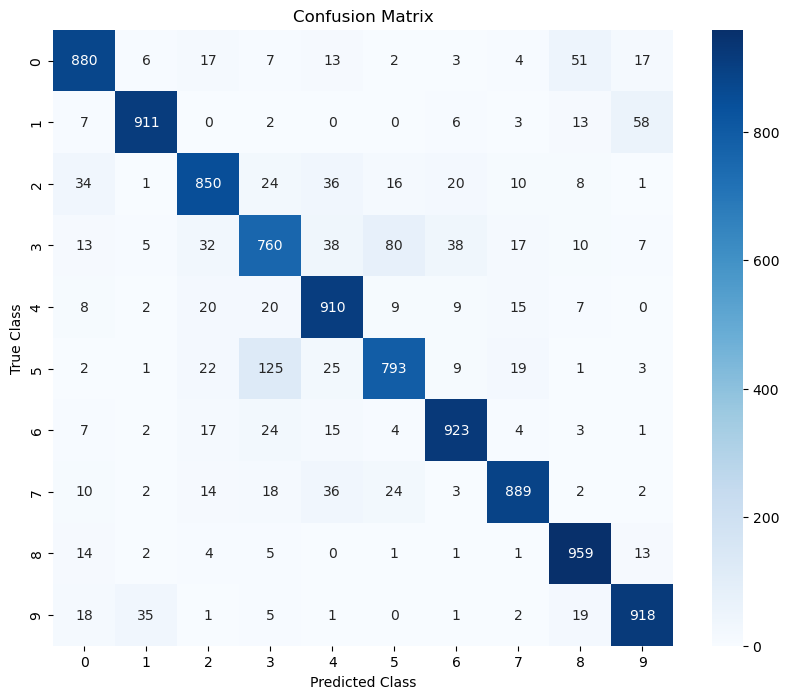

In [18]:
import matplotlib.pyplot as plt

# Retrieve history data
train_loss = history_fine.history['loss']
val_loss = history_fine.history['val_loss']
train_accuracy = history_fine.history['accuracy']
val_accuracy = history_fine.history['val_accuracy']
epochs_range = range(len(train_loss))

# Plot Loss
plt.figure(figsize=(12, 6))
plt.plot(epochs_range, train_loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

# Plot Accuracy
plt.figure(figsize=(12, 6))
plt.plot(epochs_range, train_accuracy, label="Training Accuracy")
plt.plot(epochs_range, val_accuracy, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Predict on validation data
# Use the original val_labels_np for true classes
val_predictions = model.predict(val_generator)
val_pred_classes = np.argmax(val_predictions, axis=1)

# Classification report
# Use the original val_labels_np for classification_report and confusion_matrix
# Since val_labels_np are integer labels, we need to convert the one-hot encoded val_labels back to integers
true_val_labels_int = np.argmax(val_labels, axis=1)
report = classification_report(true_val_labels_int, val_pred_classes, target_names=[str(i) for i in range(num_classes)]) # Use generated class names
print("Classification Report:\n")
print(report)

# Confusion matrix
conf_matrix = confusion_matrix(true_val_labels_int, val_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

## Display Predicted Class Probabilities
In this section, we will display the predicted class probabilities for the validation dataset. This helps in understanding how confident the model is about its predictions for each sample.

In [22]:
# Display predicted class probabilities for validation data
val_labels = labels
val_predictions = model.predict(val_generator)  # Probabilities for each class
val_pred_classes = np.argmax(val_predictions, axis=1)  # Predicted classes

# Define class indices manually
class_indices = {i: label for i, label in enumerate(labels)}  # Assuming `labels` is a list of class names

# Display probabilities for the first 10 samples
for i in range(10):
    true_class = class_indices[np.argmax(val_labels[i])]  # Convert one-hot encoded labels to class index
    predicted_class = class_indices[val_pred_classes[i]]
    confidence = val_predictions[i][val_pred_classes[i]] * 100  # Confidence of the predicted class
    print(f"Sample {i + 1}:")
    print(f"  True Class: {true_class}")
    print(f"  Predicted Class: {predicted_class}")
    print(f"  Confidence: {confidence:.2f}%")
    print()

157/157 ━━━━━━━━━━━━━━━━━━━━ 53s 338ms/step
Sample 1:
  True Class: 0
  Predicted Class: 3
  Confidence: 97.84%

Sample 2:
  True Class: 0
  Predicted Class: 8
  Confidence: 99.78%

Sample 3:
  True Class: 0
  Predicted Class: 8
  Confidence: 98.27%

Sample 4:
  True Class: 0
  Predicted Class: 0
  Confidence: 99.64%

Sample 5:
  True Class: 0
  Predicted Class: 6
  Confidence: 100.00%

Sample 6:
  True Class: 0
  Predicted Class: 6
  Confidence: 99.95%

Sample 7:
  True Class: 0
  Predicted Class: 1
  Confidence: 98.96%

Sample 8:
  True Class: 0
  Predicted Class: 6
  Confidence: 99.92%

Sample 9:
  True Class: 0
  Predicted Class: 3
  Confidence: 99.84%

Sample 10:
  True Class: 0
  Predicted Class: 1
  Confidence: 92.08%



## TensorFlow Lite Conversion and Quantization

TensorFlow Lite (TFLite) is a lightweight version of TensorFlow that is designed for deploying machine learning models on mobile, edge, and IoT devices. In this section, we will:

1. Convert the trained Keras model to a TensorFlow Lite model.
2. Quantize the TensorFlow Lite model for reduced size and improved performance.

In [ ]:
# Convert the trained Keras model to TensorFlow Lite format
tflite_converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = tflite_converter.convert()

# Save the TFLite model
tflite_model_path = "model/classification.tflite"
with open(tflite_model_path, "wb") as f:
    f.write(tflite_model)

print(f"TensorFlow Lite model saved at: {tflite_model_path}")

INFO:tensorflow:Assets written to: /tmp/tmpxqfqicmw/assets


INFO:tensorflow:Assets written to: /tmp/tmpxqfqicmw/assets


TensorFlow Lite model saved at: model/classification.tflite


2025-05-26 09:41:34.945721: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2025-05-26 09:41:34.945746: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2025-05-26 09:41:34.945912: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpxqfqicmw
2025-05-26 09:41:34.965825: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2025-05-26 09:41:34.965855: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpxqfqicmw
2025-05-26 09:41:35.037077: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2025-05-26 09:41:35.738815: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpxqfqicmw
2025-05-26 09:41:35.960719: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 1014806

In [ ]:
# Define a representative dataset generator for quantization
def representative_data_gen():
    # Iterace přes validační dataset nebo jiný vhodný dataset
    dataset_list = tf.data.Dataset.list_files(DATASET_PATH + "/*/*/*")
    for i, image_path in enumerate(dataset_list.take(100)):  # Limitujeme na 100 vzorků
        image = tf.io.read_file(image_path)
        image = tf.io.decode_png(image, channels=args.image_channels)  # Přizpůsobení počtu kanálů
        image = tf.image.resize(image, [args.image_width, args.image_height])
        image = tf.cast(image, tf.float32) / 255.0  # Normalizace
        image = tf.expand_dims(image, 0)  # Přidání dimenze pro batch
        yield [image]

# Configure the converter for quantization
tflite_converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_converter.representative_dataset = representative_data_gen
tflite_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
tflite_converter.target_spec.supported_types = [tf.int8]
tflite_converter.inference_input_type = tf.uint8
tflite_converter.inference_output_type = tf.uint8

# Convert and save the quantized TFLite model
try:
    quantized_model = tflite_converter.convert()
    quantized_model_path = f"{ROOT_PATH}/model/classification_q.tflite"
    with open(quantized_model_path, "wb") as f:
        f.write(quantized_model)
    print(f"Quantized TFLite model saved at {quantized_model_path}")
except Exception as e:
    print(f"Error during quantization: {e}")

INFO:tensorflow:Assets written to: /tmp/tmp0441_ixt/assets


INFO:tensorflow:Assets written to: /tmp/tmp0441_ixt/assets
/home/zboucek/anaconda3/envs/tf/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2025-05-26 09:41:52.370536: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2025-05-26 09:41:52.370561: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2025-05-26 09:41:52.370724: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp0441_ixt
2025-05-26 09:41:52.403132: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2025-05-26 09:41:52.403163: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp0441_ixt
2025-05-26 09:41:52.512110: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2025-05-26

Quantized TFLite model saved at /home/zboucek/mygit/cf/aideck-gap8-examples/examples/ai/classification/model/classification_q.tflite


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


In [ ]:
# Testing the model on validation data
batch_images, batch_labels = next(iter(val_generator))  # A single batch from the validation set
logits = model(batch_images)
prediction = np.argmax(logits, axis=1)
truth = np.argmax(batch_labels, axis=1)

keras_accuracy = tf.keras.metrics.Accuracy()
keras_accuracy.update_state(prediction, truth)
print(f"Raw Keras model accuracy: {keras_accuracy.result().numpy():.3%}")

# Helper function to set input tensor for the TFLite interpreter
def set_input_tensor(interpreter, input_image):
    input_details = interpreter.get_input_details()[0]
    tensor_index = input_details["index"]
    input_tensor = interpreter.tensor(tensor_index)()[0]
    input_tensor[:, :] = input_image

# Helper function to classify an image using the TFLite interpreter
def classify_image(interpreter, input_image):
    set_input_tensor(interpreter, input_image)
    interpreter.invoke()
    output_details = interpreter.get_output_details()[0]
    output = interpreter.get_tensor(output_details["index"])
    # Dequantize results
    scale, zero_point = output_details["quantization"]
    output = scale * (output - zero_point)
    return np.argmax(output)

# Perform inference using the quantized TFLite model
try:
    interpreter = tf.lite.Interpreter(model_path=quantized_model_path)
    interpreter.allocate_tensors()

    # Compare all predictions with ground truth
    tflite_accuracy = tf.keras.metrics.Accuracy()
    batch_prediction = []
    batch_truth = np.argmax(batch_labels, axis=1)

    for i in range(len(batch_images)):
        prediction = classify_image(interpreter, batch_images[i])
        batch_prediction.append(prediction)

    tflite_accuracy.update_state(batch_prediction, batch_truth)
    print(f"Quantized TFLite model accuracy: {tflite_accuracy.result().numpy():.3%}")
except Exception as e:
    print(f"Error testing quantized model: {e}")

Raw Keras model accuracy: 50.000%
Quantized TFLite model accuracy: 50.000%
